In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Q42_smartphone_battery.csv")

print(df.head())
print(df.shape)

  device_log_id  screen_on_time_hours application_category network_type  \
0        BT0001                   4.1         Productivity         WiFi   
1        BT0002                   0.5               Gaming           4G   
2        BT0003                   2.5         Productivity           4G   
3        BT0004                   4.8                Video         WiFi   
4        BT0005                   3.3           Navigation           5G   

   battery_temperature_c  battery_consumption_percent  
0                   38.1                          6.4  
1                   43.4                          9.3  
2                   45.2                          8.2  
3                   45.3                         34.6  
4                   46.4                         30.0  
(123, 6)


In [2]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   device_log_id                123 non-null    object 
 1   screen_on_time_hours         123 non-null    float64
 2   application_category         122 non-null    object 
 3   network_type                 122 non-null    object 
 4   battery_temperature_c        122 non-null    float64
 5   battery_consumption_percent  123 non-null    float64
dtypes: float64(3), object(3)
memory usage: 5.9+ KB
None
       screen_on_time_hours  battery_temperature_c  \
count            123.000000             122.000000   
mean               4.264228              36.916393   
std                2.168747               7.001928   
min                0.500000              25.100000   
25%                2.500000              30.275000   
50%                3.800000              38.800000 

In [3]:
print(df.isnull().sum())

device_log_id                  0
screen_on_time_hours           0
application_category           1
network_type                   1
battery_temperature_c          1
battery_consumption_percent    0
dtype: int64


In [4]:
print("Duplicate rows:", df.duplicated().sum())

print(df[df.duplicated('device_log_id', keep=False)])

Duplicate rows: 3
    device_log_id  screen_on_time_hours application_category network_type  \
35         BT0036                   3.5           Navigation           5G   
81         BT0082                   1.8               Social           5G   
103        BT0104                   6.0               Gaming           5G   
120        BT0082                   1.8               Social           5G   
121        BT0104                   6.0               Gaming           5G   
122        BT0036                   3.5           Navigation           5G   

     battery_temperature_c  battery_consumption_percent  
35                    41.0                         41.6  
81                    44.6                         11.5  
103                   42.4                         77.3  
120                   44.6                         11.5  
121                   42.4                         77.3  
122                   41.0                         41.6  


In [5]:
df = df.drop_duplicates(subset='device_log_id', keep='first')
print(df.shape)

(120, 6)


In [9]:
df['application_category'] = df['application_category'].fillna(
    df['application_category'].mode()[0]
)

df['network_type'] = df['network_type'].fillna(
    df['network_type'].mode()[0]
)

df['battery_temperature_c'] = df['battery_temperature_c'].fillna(
    df['battery_temperature_c'].median()
)
print(df.isnull().sum())

device_log_id                  0
screen_on_time_hours           0
application_category           0
network_type                   0
battery_temperature_c          0
battery_consumption_percent    0
dtype: int64


In [11]:
print(df[
    (df['battery_consumption_percent'] < 0) |
    (df['battery_consumption_percent'] > 100)
])
print(df['battery_temperature_c'].describe())

Empty DataFrame
Columns: [device_log_id, screen_on_time_hours, application_category, network_type, battery_temperature_c, battery_consumption_percent]
Index: []
count    120.000000
mean      36.785833
std        6.997566
min       25.100000
25%       30.175000
50%       38.500000
75%       42.550000
max       47.700000
Name: battery_temperature_c, dtype: float64


In [13]:
app_consumption = df.groupby(
    'application_category'
)['battery_consumption_percent'].mean().sort_values(ascending=False)

print(app_consumption)

application_category
Gaming          56.922727
Navigation      43.595652
Video           38.454167
Social          24.466667
Productivity    19.200000
Name: battery_consumption_percent, dtype: float64


In [14]:
network_consumption = df.groupby(
    'network_type'
)['battery_consumption_percent'].mean().sort_values(ascending=False)

print(network_consumption)

network_type
5G      38.902128
WiFi    37.227027
4G      29.497222
Name: battery_consumption_percent, dtype: float64


In [15]:
df['battery_drain_per_hour'] = (
    df['battery_consumption_percent'] /
    df['screen_on_time_hours']
)

print(df[
    ['device_log_id',
     'screen_on_time_hours',
     'battery_consumption_percent',
     'battery_drain_per_hour']
].head())

  device_log_id  screen_on_time_hours  battery_consumption_percent  \
0        BT0001                   4.1                          6.4   
1        BT0002                   0.5                          9.3   
2        BT0003                   2.5                          8.2   
3        BT0004                   4.8                         34.6   
4        BT0005                   3.3                         30.0   

   battery_drain_per_hour  
0                1.560976  
1               18.600000  
2                3.280000  
3                7.208333  
4                9.090909  


In [16]:
df['usage_intensity'] = pd.cut(
    df['screen_on_time_hours'],
    bins=[-np.inf, 2, 5, np.inf],
    labels=['Low', 'Medium', 'High']
)

print(df[
    ['screen_on_time_hours', 'usage_intensity']
].head())

   screen_on_time_hours usage_intensity
0                   4.1          Medium
1                   0.5             Low
2                   2.5          Medium
3                   4.8          Medium
4                   3.3          Medium


In [17]:
intensity_analysis = df.groupby(
    'usage_intensity',
    observed=False
)['battery_consumption_percent'].mean()

print(intensity_analysis)

usage_intensity
Low       11.350000
Medium    26.466667
High      58.938095
Name: battery_consumption_percent, dtype: float64


In [18]:
df.to_csv(
    'cleaned_smartphone_battery.csv',
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


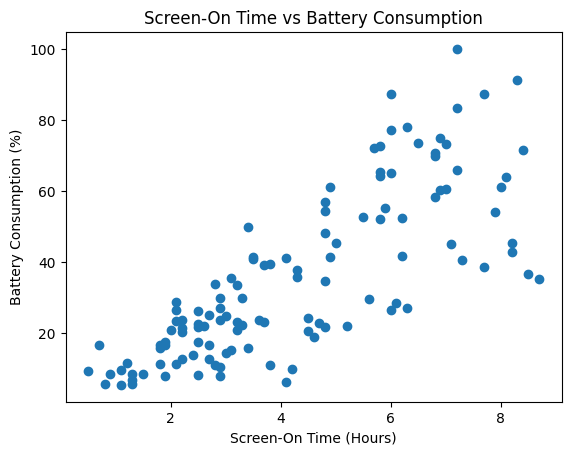

In [19]:
import matplotlib.pyplot as plt

plt.scatter(df["screen_on_time_hours"],
            df["battery_consumption_percent"])

plt.xlabel("Screen-On Time (Hours)")
plt.ylabel("Battery Consumption (%)")
plt.title("Screen-On Time vs Battery Consumption")
plt.show()

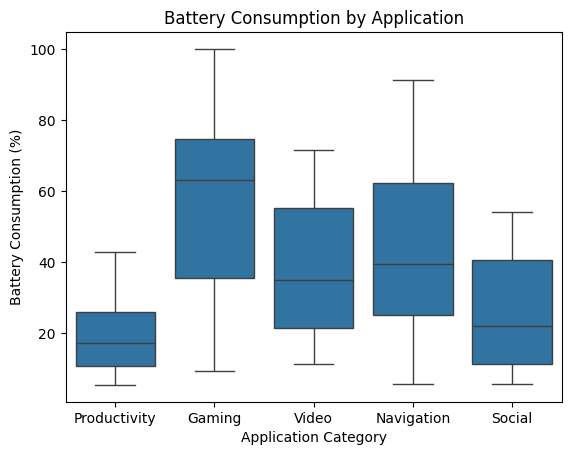

In [20]:
import seaborn as sns

sns.boxplot(x="application_category",
            y="battery_consumption_percent",
            data=df)

plt.xlabel("Application Category")
plt.ylabel("Battery Consumption (%)")
plt.title("Battery Consumption by Application")
plt.show()